# Emotion Detection Extension: IMDb Movie Reviews

This notebook extends the original sentiment analysis project by adding **emotion detection** using a pretrained transformer model.

## Introduction

Sentiment analysis predicts whether a review is generally positive or negative.

Emotion detection goes one level deeper by identifying the **specific emotion** expressed in the text (for example, joy, anger, sadness, fear, surprise, disgust, or neutral).

This helps uncover richer patterns in how users describe movie experiences.

## Load Dataset

In [7]:
# Core libraries
from pathlib import Path

import matplotlib.pyplot as plt
import nltk
import pandas as pd
import re
import seaborn as sns
import torch

try:
    from transformers import pipeline
except ModuleNotFoundError as exc:
    raise ModuleNotFoundError(
        "transformers is not installed. Install dependencies with: pip install -r requirements.txt"
    ) from exc

# Plot style for cleaner visuals
sns.set_theme(style="whitegrid")
pd.set_option("display.max_colwidth", 120)

In [8]:
# Locate dataset relative to the notebook location
dataset_path = Path("../data/IMDB Dataset.csv")
if not dataset_path.exists():
    dataset_path = Path("data/IMDB Dataset.csv")

df = pd.read_csv(dataset_path)
print(f"Loaded dataset shape: {df.shape}")
df[["review", "sentiment"]].head()

Loaded dataset shape: (50000, 2)


,review,sentiment
0,"One of the other reviewers has mentioned that after watching just 1 Oz episode you'll be hooked. They are right, as ...",positive
1,A wonderful little production. <br /><br />The filming technique is very unassuming- very old-time-BBC fashion and g...,positive
2,"I thought this was a wonderful way to spend time on a too hot summer weekend, sitting in the air conditioned theater...",positive
3,Basically there's a family where a little boy (Jake) thinks there's a zombie in his closet & his parents are fightin...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is a visually stunning film to watch. Mr. Mattei offers us a vivid portr...",positive


In [13]:
# Sample a subset for fast local execution
sample_size = 800  # keep between 500 and 1000 for laptop-friendly runtime
sample_df = df.sample(n=min(sample_size, len(df)), random_state=42).copy()

# Normalize sentiment to numeric (positive=1, negative=0)
if pd.api.types.is_numeric_dtype(sample_df["sentiment"]):
    sample_df["sentiment"] = sample_df["sentiment"].astype(int)
else:
    sample_df["sentiment"] = (
        sample_df["sentiment"]
        .astype(str)
        .str.strip()
        .str.lower()
        .map({"positive": 1, "negative": 0})
    )

if sample_df["sentiment"].isna().any():
    raise ValueError("Unexpected sentiment values found. Expected only 'positive' or 'negative'.")

print(f"Working sample shape: {sample_df.shape}")
sample_df["sentiment"].value_counts(dropna=False)

Working sample shape: (800, 2)


sentiment
0    413
1    387
Name: count, dtype: int64

## Text Preprocessing

In [14]:
# Download stopwords once (safe to re-run)
nltk.download("stopwords", quiet=True)
from nltk.corpus import stopwords

stop_words = set(stopwords.words("english"))

def clean_text(text: str) -> str:
    """Lowercase text, remove HTML, strip special chars, and remove stopwords."""
    text = str(text).lower()
    text = re.sub(r"<.*?>", " ", text)  # remove HTML tags
    text = re.sub(r"[^a-z\s]", " ", text)  # keep letters and spaces only
    tokens = [token for token in text.split() if token not in stop_words]
    return " ".join(tokens)

sample_df["clean_review"] = sample_df["review"].apply(clean_text)
sample_df[["review", "clean_review"]].head(3)

,review,clean_review
33553,"I really liked this Summerslam due to the look of the arena, the curtains and just the look overall was interesting ...",really liked summerslam due look arena curtains look overall interesting reason anyways could one best summerslam ev...
9427,Not many television shows appeal to quite as many different kinds of fans like Farscape does...I know youngsters and...,many television shows appeal quite many different kinds fans like farscape know youngsters years old fans male femal...
199,The film quickly gets to a major chase scene with ever increasing destruction. The first really bad thing is the guy...,film quickly gets major chase scene ever increasing destruction first really bad thing guy hijacking steven seagal w...


## Apply Emotion Detection Model

In [15]:
# Load pretrained emotion model from HuggingFace
emotion_classifier = pipeline(
    task="text-classification",
    model="j-hartmann/emotion-english-distilroberta-base"
 )

def predict_emotions(texts, batch_size: int = 16):
    """Run batched inference and return (label, confidence) tuples."""
    results = []
    for start_idx in range(0, len(texts), batch_size):
        batch = texts[start_idx:start_idx + batch_size]
        preds = emotion_classifier(batch, truncation=True, max_length=256)
        results.extend(
            (pred["label"].lower(), float(pred["score"]))
            for pred in preds
        )
    return results

emotions = predict_emotions(sample_df["clean_review"].tolist(), batch_size=16)
sample_df["emotion"] = [e[0] for e in emotions]
sample_df["confidence"] = [e[1] for e in emotions]

sample_df[["review", "sentiment", "emotion", "confidence"]].head()

Loading weights:   0%|          | 0/105 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: j-hartmann/emotion-english-distilroberta-base
Key                             | Status     |  | 
--------------------------------+------------+--+-
roberta.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


,review,sentiment,emotion,confidence
33553,"I really liked this Summerslam due to the look of the arena, the curtains and just the look overall was interesting ...",1,surprise,0.382333
9427,Not many television shows appeal to quite as many different kinds of fans like Farscape does...I know youngsters and...,1,joy,0.367990
199,The film quickly gets to a major chase scene with ever increasing destruction. The first really bad thing is the guy...,0,joy,0.390122
12447,Jane Austen would definitely approve of this one!<br /><br />Gwyneth Paltrow does an awesome job capturing the attit...,1,surprise,0.536874
39489,"Expectations were somewhat high for me when I went to see this movie, after all I thought Steve Carell could do no w...",0,fear,0.978089


## Results & Visualization

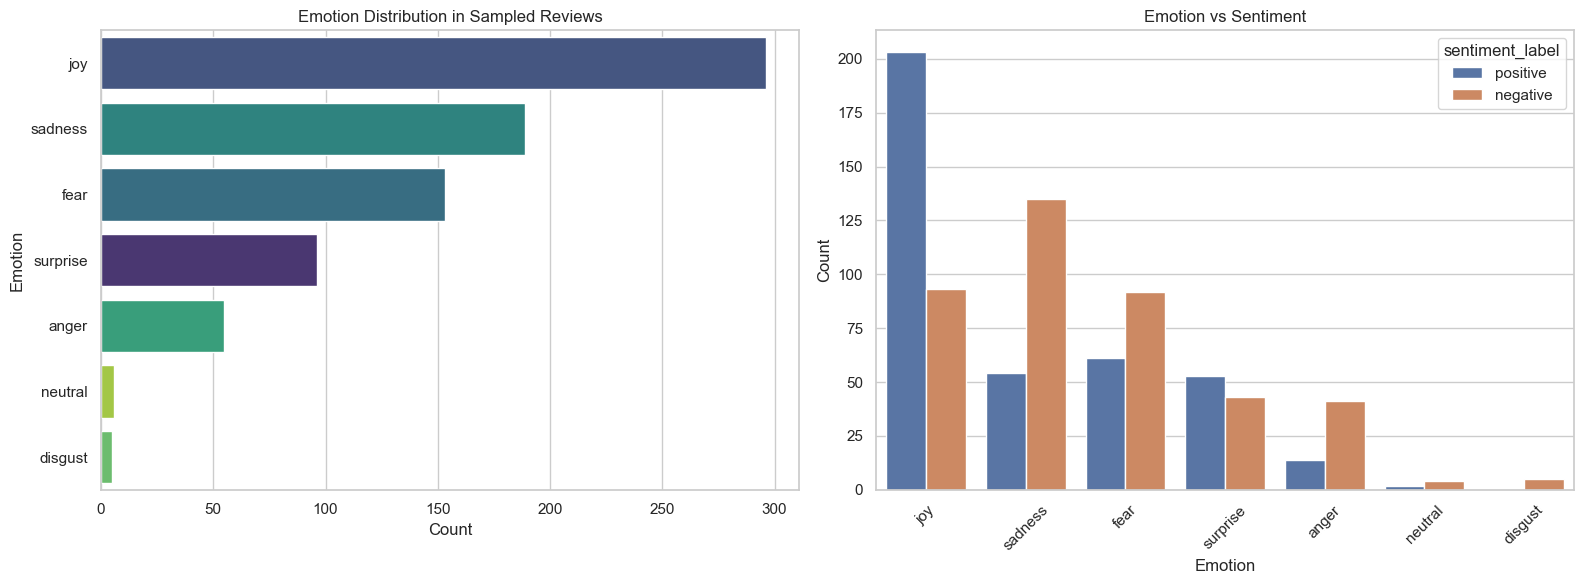

In [16]:
# Build sentiment labels for easier chart interpretation
if pd.api.types.is_numeric_dtype(sample_df["sentiment"]):
    sample_df["sentiment_label"] = sample_df["sentiment"].map({1: "positive", 0: "negative"})
else:
    sample_df["sentiment_label"] = sample_df["sentiment"].astype(str).str.lower()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Emotion distribution
emotion_order = sample_df["emotion"].value_counts().index
sns.countplot(
    data=sample_df,
    y="emotion",
    order=emotion_order,
    hue="emotion",
    palette="viridis",
    legend=False,
    ax=axes[0]
 )
axes[0].set_title("Emotion Distribution in Sampled Reviews")
axes[0].set_xlabel("Count")
axes[0].set_ylabel("Emotion")

# Emotion vs sentiment comparison
sns.countplot(
    data=sample_df,
    x="emotion",
    hue="sentiment_label",
    order=emotion_order,
    ax=axes[1]
 )
axes[1].set_title("Emotion vs Sentiment")
axes[1].set_xlabel("Emotion")
axes[1].set_ylabel("Count")
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

## Insights

In [17]:
# Show sample rows with review, sentiment, and detected emotion
display(sample_df[["review", "sentiment", "emotion"]].head(10))

# Print compact summary insights
emotion_counts = sample_df["emotion"].value_counts()
emotion_sentiment = pd.crosstab(sample_df["emotion"], sample_df["sentiment_label"], normalize="index")

print("Top detected emotions:")
print(emotion_counts.head(5))
print()
print("Emotion distribution within each emotion class (row-wise proportions):")
print((emotion_sentiment * 100).round(2).astype(str) + "%")
print()

top_emotion = emotion_counts.idxmax()
positive_share = (sample_df["sentiment"] == 1).sum() / len(sample_df) * 100

print("Summary insights:")
print(f"- Most common detected emotion: {top_emotion}")
print(f"- Positive sentiment share in sample: {positive_share:.1f}%")
print("- Emotion labels provide finer-grained context beyond binary sentiment.")

,review,sentiment,emotion
33553,"I really liked this Summerslam due to the look of the arena, the curtains and just the look overall was interesting ...",1,surprise
9427,Not many television shows appeal to quite as many different kinds of fans like Farscape does...I know youngsters and...,1,joy
199,The film quickly gets to a major chase scene with ever increasing destruction. The first really bad thing is the guy...,0,joy
12447,Jane Austen would definitely approve of this one!<br /><br />Gwyneth Paltrow does an awesome job capturing the attit...,1,surprise
39489,"Expectations were somewhat high for me when I went to see this movie, after all I thought Steve Carell could do no w...",0,fear
42724,"I've watched this movie on a fairly regular basis for most of my life, and it never gets old. For all the snide rema...",1,joy
10822,"For once a story of hope highlighted over the tragic reality our youth face. Favela Rising draws one into a scary, u...",1,fear
49498,"Okay, I didn't get the Purgatory thing the first time I watched this episode. It seemed like something significant w...",1,joy
4144,I was very disappointed with this series. It had lots of cool graphics and that's about it. The level of detail it w...,0,sadness
36958,"The first 30 minutes of Tinseltown had my finger teetering on the remote, poised to flick around to watch something ...",0,joy


Top detected emotions:
emotion
joy         296
sadness     189
fear        153
surprise     96
anger        55
Name: count, dtype: int64

Emotion distribution within each emotion class (row-wise proportions):
sentiment_label negative positive
emotion                          
anger             74.55%   25.45%
disgust           100.0%     0.0%
fear              60.13%   39.87%
joy               31.42%   68.58%
neutral           66.67%   33.33%
sadness           71.43%   28.57%
surprise          44.79%   55.21%

Summary insights:
- Most common detected emotion: joy
- Positive sentiment share in sample: 48.4%
- Emotion labels provide finer-grained context beyond binary sentiment.


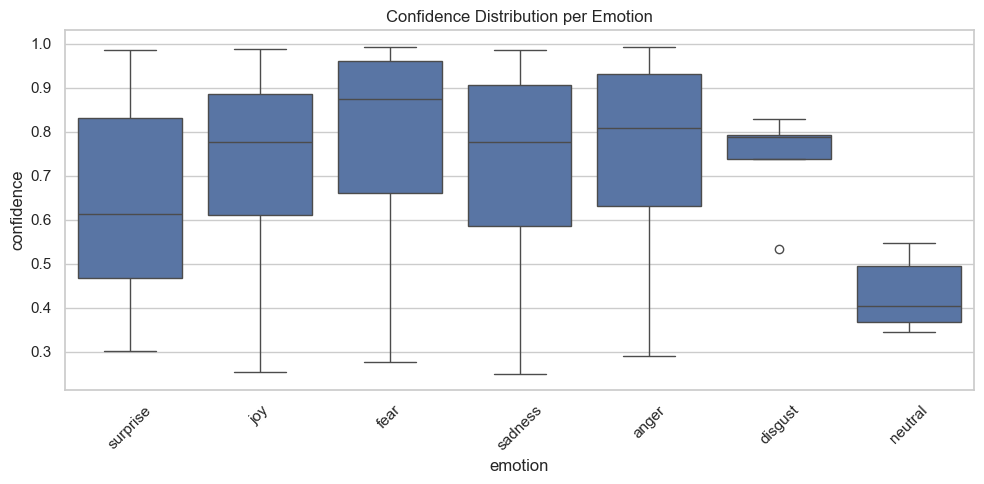

In [18]:
# Confidence distribution by detected emotion
plt.figure(figsize=(10, 5))
sns.boxplot(x="emotion", y="confidence", data=sample_df)
plt.xticks(rotation=45)
plt.title("Confidence Distribution per Emotion")
plt.tight_layout()
plt.show()